# 1. Setup

### 1.1 Import libraries and configuration

In [115]:
import pandas as pd, numpy as np             # Data manipulation 
from matplotlib import pyplot as plt         # Graphing
import seaborn as sns                        # Graphing

import statsmodels.api as sm                    # Statistical analysis
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from scipy import stats                      # Stats
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.impute import KNNImputer

#sns.set(style="white")                       # Tuning the style of charts
import warnings                              # Disable some warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

pd.set_option("display.precision", 2)

# 2. Functions

### 2.1 Initial / EDA

In [116]:
def dataImport(input):
    df = pd.read_csv(f'{input}.csv',sep="\t")
    return df

In [117]:
def dataInfo(df):
    print(df.shape) 
    print(df.columns)  
    print(df.dtypes)
    print(df.isna().sum()) 

### 2.2 Data Cleaning

#### Nulls

In [118]:
def nullReplace(df):
    df = df.replace('(null)', np.nan, inplace=True)  

In [119]:
def imputeNullsTrain(df):
    colsImpute = ['ActualFlightTime', 'ActualTotalFuel','ActualTOW', 'FLownPassengers', 'BagsCount', 'FlightBagsWeight']

    imputer = KNNImputer(n_neighbors=3)

    df[colsImpute] = imputer.fit_transform(df[colsImpute])

def imputeNullsTest(df):
    colsImpute = ['ActualFlightTime', 'ActualTotalFuel', 'FLownPassengers', 'BagsCount', 'FlightBagsWeight']

    imputer = KNNImputer(n_neighbors=3)

    df[colsImpute] = imputer.fit_transform(df[colsImpute])

#### Data Types

In [120]:
def dataTypeTransformTrain(df):
    nullsColumns = ['ActualTOW', 'FLownPassengers', 'BagsCount', 'FlightBagsWeight']

    df[nullsColumns] = df[nullsColumns].apply(pd.to_numeric, errors='coerce')

    df[nullsColumns] = df[nullsColumns].fillna(df[nullsColumns].mean())

    df[nullsColumns] = df[nullsColumns].astype('int64')

def dataTypeTransformTest(df):
    nullsColumns = ['FLownPassengers', 'BagsCount', 'FlightBagsWeight']

    df[nullsColumns] = df[nullsColumns].apply(pd.to_numeric, errors='coerce')

    df[nullsColumns] = df[nullsColumns].fillna(df[nullsColumns].mean())

    df[nullsColumns] = df[nullsColumns].astype('int64')

#### Outliers

In [121]:
def remove_outliers_iqr(df, cols):
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

#### Duplicates

In [122]:
# I noticed a certain number of flights which were on the same day and shared some characteristics which made them highly unlikely

def dropDuplicates(df):
    sameFlightTime = ['DepartureDate', 'DepartureAirport', 'ArrivalAirport','ActualFlightTime']
    sameTotalFuel = ['DepartureDate', 'DepartureAirport', 'ArrivalAirport','ActualTotalFuel']
    sameFLownPassengers = ['DepartureDate', 'DepartureAirport', 'ArrivalAirport','FLownPassengers']
    sameFlightBagsWeight = ['DepartureDate', 'DepartureAirport', 'ArrivalAirport','FlightBagsWeight']
    sameBagsCount = ['DepartureDate', 'DepartureAirport', 'ArrivalAirport','BagsCount']

    df = df.drop_duplicates(subset=sameFlightTime, keep='first') 
    df = df.drop_duplicates(subset=sameTotalFuel, keep='first') 
    df = df.drop_duplicates(subset=sameFLownPassengers, keep='first') 
    df = df.drop_duplicates(subset=sameFlightBagsWeight, keep='first') 
    df = df.drop_duplicates(subset=sameBagsCount, keep='first') 

    return df

### 2.3 Execution

In [123]:
def importAndProcess(selection):
    
    df = dataImport(selection)
    cols = ['ActualFlightTime', 'ActualTotalFuel', 'ActualTOW', 'FLownPassengers','BagsCount', 'FlightBagsWeight']

    nullReplace(df)
    
    if selection == 'training':
        imputeNullsTrain(df)
    elif selection == 'validation':
        imputeNullsTest(df)

    if selection == 'training':
        dataTypeTransformTrain(df)
    elif selection == 'validation':
        dataTypeTransformTest(df)

    if selection == 'training':
        df = dropDuplicates(df)

    if selection == 'training':
        df = remove_outliers_iqr(df, cols)


    return df

# 3. Import and Data Cleaning

## 3.1 Preprocessing Function Calls

In [124]:
validationCleaned = importAndProcess('validation')
trainingCleaned = importAndProcess('training')

## 3.2 Feature Correlation Analysis

This was carried out during the EDA phase - I have just left it here to include the visualisation in the notebook

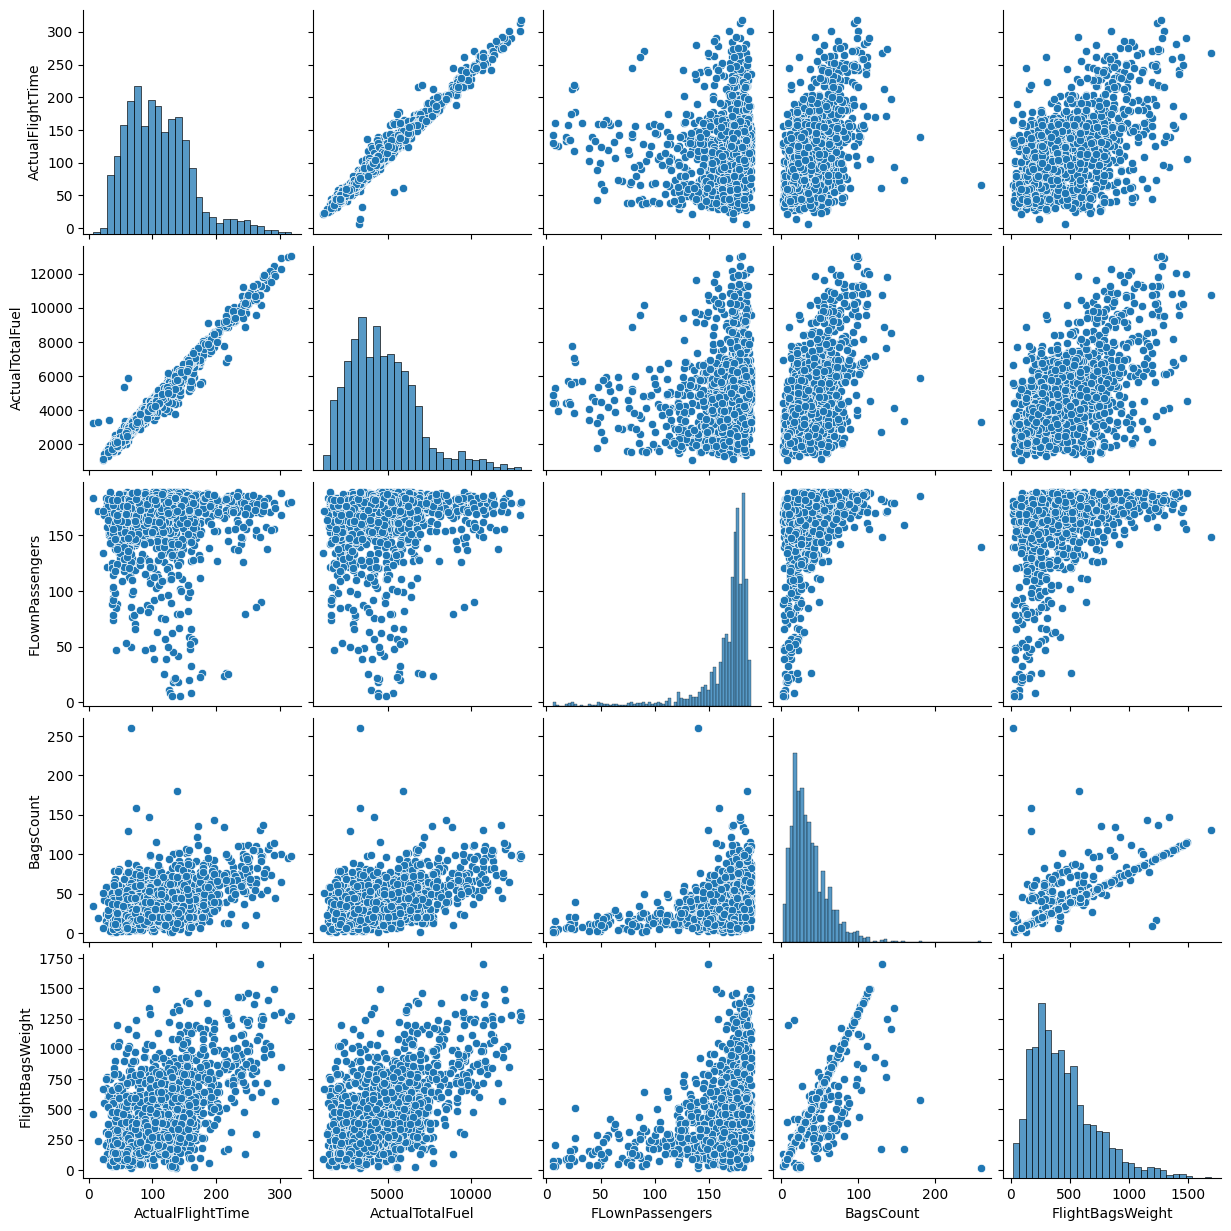

In [125]:
X = validationCleaned[['ActualFlightTime', 'ActualTotalFuel', 'FLownPassengers', 'BagsCount', 'FlightBagsWeight']]
Y = trainingCleaned[['ActualFlightTime', 'ActualTotalFuel', 'FLownPassengers', 'BagsCount', 'FlightBagsWeight']]

pairplot_X = sns.pairplot(X)

# 4. Linear Regression

In [126]:
df = trainingCleaned

## 4.1 Test/Train Split

In [127]:
X = df[['ActualFlightTime', 'ActualTotalFuel', 'FLownPassengers','BagsCount', 'FlightBagsWeight']] 
y = df['ActualTOW'] 

df_model, df_reserved = train_test_split(df, test_size=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Sample size train dataset: ", X_train.shape)
print("Sample size test dataset: ", X_test.shape)

Sample size train dataset:  (19742, 5)
Sample size test dataset:  (4936, 5)


## 4.2 Feature Selection

### 4.2.1 Stepwise

In [128]:
# Stepwise function
def stepwise_selection(X, y, 
                       initial_list=[], 
                       threshold_in=0.05, 
                       threshold_out = 0.1, 
                       verbose=True):
    included = list(initial_list)
    while True:
        changed=False
        # forward step
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(X[included+[new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.4}'.format(best_feature, best_pval))

        # backward step
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() # null if pvalues is empty
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.argmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.4}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [129]:
result = stepwise_selection(X_train, y_train)
print("Selected features: ", result)

Add  ActualTotalFuel                with p-value 0.0
Add  FLownPassengers                with p-value 0.0
Add  ActualFlightTime               with p-value 0.0
Add  FlightBagsWeight               with p-value 2.408e-62
Selected features:  ['ActualTotalFuel', 'FLownPassengers', 'ActualFlightTime', 'FlightBagsWeight']


### 4.2.2 VIF Test

In [130]:
X = X[result] # Selected from stepwise
X_train = X_train[result]
X_test = X_test[result]

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

            Feature     VIF
0   ActualTotalFuel  410.55
1   FLownPassengers    8.97
2  ActualFlightTime  377.83
3  FlightBagsWeight    6.44


In [131]:
X = X.drop(columns=['ActualTotalFuel'])
X_train = X_train.drop(columns=['ActualTotalFuel'])
X_test = X_test.drop(columns=['ActualTotalFuel'])

# High correlation with ActualFlightTime

In [132]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

            Feature    VIF
0   FLownPassengers   8.21
1  ActualFlightTime  11.25
2  FlightBagsWeight   6.34


## 4.3 Model Training

In [133]:
model = LinearRegression()  # Initialize the model
model.fit(X_train, y_train)  # Train the model

LinearRegression()

In [134]:
y_pred = model.predict(X_test)

In [135]:
X_train
result = sm.OLS(y_train, X_train).fit()
print (result.summary())

                                 OLS Regression Results                                
Dep. Variable:              ActualTOW   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          3.129e+06
Date:                Sun, 02 Mar 2025   Prob (F-statistic):                        0.00
Time:                        21:44:26   Log-Likelihood:                     -1.8608e+05
No. Observations:               19742   AIC:                                  3.722e+05
Df Residuals:                   19739   BIC:                                  3.722e+05
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

## 4.4 Model Evaluation

In [136]:
lm = LinearRegression(fit_intercept=True)
model=lm.fit(X_train, y_train)

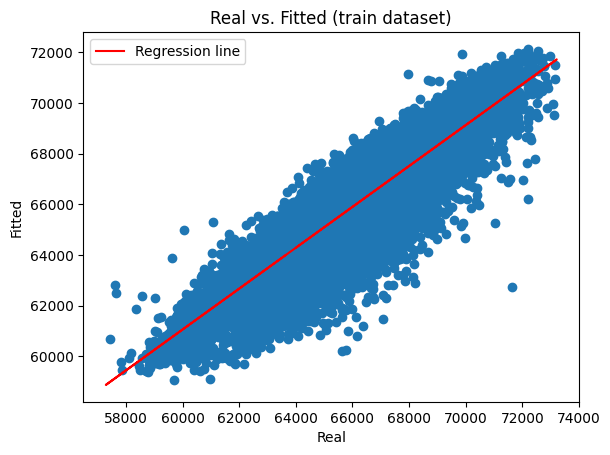

In [137]:
predictions_train = lm.predict(X_train[X_train.columns]) #only with the columns used in the model

plt.title("Real vs. Fitted (train dataset)")
plt.scatter(y_train,predictions_train)

coef = np.polyfit(y_train, predictions_train, 1)  
poly1d_fn = np.poly1d(coef)  
plt.plot(y, poly1d_fn(y), color="red", label="Regression line")

plt.xlabel("Real")
plt.ylabel("Fitted")
plt.legend()
plt.show()

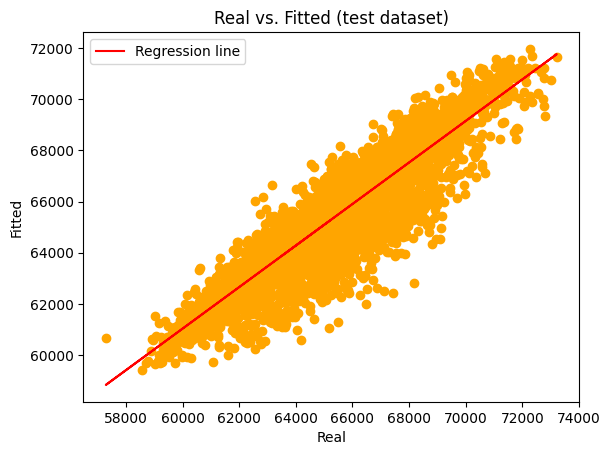

In [138]:
# test dataset
predictions_test = lm.predict(X_test[X_train.columns]) #only with the columns used in the model
plt.title("Real vs. Fitted (test dataset)")
plt.scatter(y_test,predictions_test, color="orange")

coef = np.polyfit(y_test, predictions_test, 1)  
poly1d_fn = np.poly1d(coef)  
plt.plot(y_test, poly1d_fn(y_test), color="red", label="Regression line")

plt.xlabel("Real")
plt.ylabel("Fitted")

plt.legend()
plt.show()

In [139]:
from sklearn import metrics
print("Errors:")

results = {
    'Metric': ['RMSE', 'R-squared'],
    'Train': [
        np.sqrt(metrics.mean_squared_error(y_train, predictions_train)),  # RMSE
        metrics.r2_score(y_train, predictions_train)  # R-squared
    ],
    'Test': [
        np.sqrt(metrics.mean_squared_error(y_test, predictions_test)),  # RMSE
        metrics.r2_score(y_test, predictions_test)  # R-squared
    ]
}

results_dfLR = pd.DataFrame(results).set_index('Metric')

results_dfLR

Errors:


,Train,Test
Metric,,
RMSE,1097.21,1088.89
R-squared,0.81,0.82


## 4.5 Predictions

In [140]:
validationSet = validationCleaned[['FLownPassengers','ActualFlightTime',  'FlightBagsWeight']]

validationCleaned['PredictedTOW'] = model.predict(validationSet)

outputDF = validationCleaned

In [141]:
outputDF.to_csv('predictions_SJ.csv')

# Test

In [142]:
df2 = pd.read_csv(f'predictions_SJ.csv',index_col=0)

In [143]:
df2.describe()['PredictedTOW']

count     1878.00
mean     64913.79
std       3101.42
min      52243.34
25%      63402.51
50%      65002.97
75%      66811.04
max      74817.09
Name: PredictedTOW, dtype: float64

In [144]:
trainingCleaned.describe()['ActualTOW']

count    24678.00
mean     65435.42
std       2505.06
min      57291.00
25%      63616.00
50%      65394.00
75%      67190.00
max      73213.00
Name: ActualTOW, dtype: float64

I ran the above tests to quickly confirm that my predicted values were in the same range as the cleaned dataset